<a href="https://colab.research.google.com/github/huyle31251027190/BTVN-AI-13-04-2026/blob/main/BTVN_AI_13_04_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import folium
from folium import FeatureGroup, LayerControl

# 1. Khởi tạo bản đồ với trung tâm là UEH Cơ sở A
# Tọa độ (Vĩ độ, Kinh độ)
ueh_coords = [10.7814, 106.6945]
m = folium.Map(location=ueh_coords, zoom_start=15, control_scale=True)

# 2. Tạo các lớp dữ liệu (Feature Groups) để có thể Bật/Tắt
layer_university = FeatureGroup(name='Trường Đại học')
layer_hospital = FeatureGroup(name='Bệnh viện')
layer_mall = FeatureGroup(name='Trung tâm Thương mại')
layer_public = FeatureGroup(name='Địa điểm Công cộng / Hành chính')

# 3. Thêm Marker cho điểm trung tâm (UEH) vào layer_university
folium.Marker(
    location=ueh_coords,
    popup="<b>UEH - Cơ sở A</b><br>59C Nguyễn Đình Chiểu",
    tooltip="Nhấn để xem chi tiết",
    icon=folium.Icon(color='red', icon='graduation-cap', prefix='fa')
).add_to(layer_university)

# 4. Thêm 5 Marker cho các địa điểm lân cận vào các layer tương ứng

# Địa điểm 1: Bệnh viện Nhi Đồng 2
folium.Marker(
    location=[10.7818, 106.7001],
    popup="<b>Bệnh viện Nhi Đồng 2</b><br>Bệnh viện chuyên khoa nhi tuyến cuối.",
    icon=folium.Icon(color='lightred', icon='plus', prefix='fa')
).add_to(layer_hospital)

# Địa điểm 2: Diamond Plaza
folium.Marker(
    location=[10.7808, 106.6980],
    popup="<b>Diamond Plaza</b><br>Trung tâm thương mại phức hợp.",
    icon=folium.Icon(color='blue', icon='shopping-cart', prefix='fa')
).add_to(layer_mall)

# Địa điểm 3: Bưu điện Trung tâm Sài Gòn
folium.Marker(
    location=[10.7799, 106.7000],
    popup="<b>Bưu điện Trung tâm Sài Gòn</b><br>Cơ quan bưu chính và điểm tham quan.",
    icon=folium.Icon(color='green', icon='envelope', prefix='fa')
).add_to(layer_public)

# Địa điểm 4: Hồ Con Rùa
folium.Marker(
    location=[10.7828, 106.6960],
    popup="<b>Hồ Con Rùa</b><br>Nút giao thông và công viên công cộng.",
    icon=folium.Icon(color='green', icon='tree', prefix='fa')
).add_to(layer_public)

# Địa điểm 5: Dinh Độc Lập
folium.Marker(
    location=[10.7770, 106.6953],
    popup="<b>Dinh Độc Lập</b><br>Di tích lịch sử và cơ quan hành chính.",
    icon=folium.Icon(color='green', icon='landmark', prefix='fa')
).add_to(layer_public)

# 5. Thêm các layer vào bản đồ chính
layer_university.add_to(m)
layer_hospital.add_to(m)
layer_mall.add_to(m)
layer_public.add_to(m)

# 6. Thêm bộ điều khiển Layer (LayerControl) để bật/tắt
# Phải thêm dòng này sau khi đã add toàn bộ FeatureGroup vào bản đồ
LayerControl(position='topright').add_to(m)

# 7. Hiển thị bản đồ
m

In [ ]:
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

# 1. Khởi tạo công cụ Geocoding
# Bắt buộc phải khai báo user_agent khi dùng Nominatim
geolocator = Nominatim(user_agent="ai_spatial_analysis_course")

# Xác định điểm trung tâm (Ví dụ: Chợ Bến Thành)
center_name = "Ben Thanh Market, Ho Chi Minh City"
center_location = geolocator.geocode(center_name)
center_coords = (center_location.latitude, center_location.longitude)

# Danh sách 10 địa điểm/địa chỉ cụ thể tại TP.HCM
# Sử dụng tên phổ biến để Nominatim (OpenStreetMap) dễ nhận diện
addresses = [
    "Independence Palace, Ho Chi Minh City",
    "Notre Dame Cathedral of Saigon, Ho Chi Minh City",
    "Saigon Central Post Office, Ho Chi Minh City",
    "War Remnants Museum, Ho Chi Minh City",
    "Bitexco Financial Tower, Ho Chi Minh City",
    "Saigon Opera House, Ho Chi Minh City",
    "Saigon Centre, Ho Chi Minh City",
    "Fine Arts Museum, Ho Chi Minh City",
    "Turtle Lake, Ho Chi Minh City",
    "Diamond Plaza, Ho Chi Minh City"
]

# 2. Xử lý dữ liệu: Geocoding và tính khoảng cách
locations_data = []

print("Đang xử lý dữ liệu địa lý. Vui lòng đợi...")
for addr in addresses:
    try:
        # Lấy tọa độ
        loc = geolocator.geocode(addr)
        if loc:
            coords = (loc.latitude, loc.longitude)
            # Tính khoảng cách (đơn vị: km)
            dist_km = geodesic(center_coords, coords).kilometers

            # Lưu trữ dữ liệu
            locations_data.append({
                "name": addr.split(",")[0],
                "coords": coords,
                "distance": dist_km
            })
        else:
            print(f"Không tìm thấy tọa độ cho: {addr}")

        # Tạm dừng 1 giây để tuân thủ chính sách của API
        time.sleep(1)

    except Exception as e:
        print(f"Lỗi khi xử lý {addr}: {e}")

# 3. Trực quan hóa dữ liệu bằng Folium
# Khởi tạo bản đồ tại điểm trung tâm
m = folium.Map(location=center_coords, zoom_start=14)

# Gắn Marker cho điểm trung tâm
folium.Marker(
    location=center_coords,
    popup=f"<b>Trung tâm: Chợ Bến Thành</b>",
    icon=folium.Icon(color='red', icon='star', prefix='fa')
).add_to(m)

# Gắn Marker cho 10 điểm và vẽ đường nối (PolyLine) dựa trên lý thuyết trong slide
for data in locations_data:
    # Điểm ghim cho từng vị trí
    folium.Marker(
        location=data['coords'],
        popup=f"<b>{data['name']}</b><br>Cách trung tâm: {data['distance']:.2f} km",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

    # Vẽ đường nối PolyLine từ Trung tâm đến Địa điểm này
    # Tham chiếu slide: folium.PolyLine(loc, color='red', weight=15, opacity=0.8)
    path_coords = [center_coords, data['coords']]
    folium.PolyLine(
        locations=path_coords,
        color='orange',
        weight=3,
        opacity=0.7,
        tooltip=f"{data['distance']:.2f} km"
    ).add_to(m)

print("Xử lý hoàn tất! Đang hiển thị bản đồ...")
# Hiển thị bản đồ
m

Đang xử lý dữ liệu địa lý. Vui lòng đợi...
Không tìm thấy tọa độ cho: Notre Dame Cathedral of Saigon, Ho Chi Minh City
Xử lý hoàn tất! Đang hiển thị bản đồ...


In [ ]:
import folium
from folium.plugins import HeatMap
import numpy as np

# 1. Khởi tạo bản đồ trung tâm TP.HCM
center_hcm = [10.7769, 106.7009]
m_heat = folium.Map(location=center_hcm, zoom_start=12, tiles='CartoDB positron')
# Dùng nền 'CartoDB positron' (màu sáng) để làm nổi bật màu sắc của Heatmap

# 2. Giả lập dữ liệu không gian (Tọa độ khách hàng / Đơn hàng)
# Thầy sử dụng phân phối chuẩn (Normal Distribution) để tạo các "cụm" (clusters) tập trung
np.random.seed(42) # Cố định seed để kết quả giả lập không đổi sau mỗi lần chạy

# Cụm 1: Khu vực Quận 1 / Quận 3 (Mật độ rất cao - 200 điểm)
cluster_q1 = np.random.normal(loc=[10.7769, 106.7009], scale=0.01, size=(200, 2)).tolist()

# Cụm 2: Khu vực Quận 7 / Phú Mỹ Hưng (Mật độ cao - 150 điểm)
cluster_q7 = np.random.normal(loc=[10.7325, 106.7145], scale=0.015, size=(150, 2)).tolist()

# Cụm 3: Khu vực Tân Bình / Sân bay (Mật độ vừa - 100 điểm)
cluster_tb = np.random.normal(loc=[10.8015, 106.6558], scale=0.012, size=(100, 2)).tolist()

# Điểm nhiễu rải rác toàn thành phố (100 điểm)
noise = np.random.uniform(low=[10.70, 106.60], high=[10.85, 106.80], size=(100, 2)).tolist()

# Tổng hợp toàn bộ dữ liệu tọa độ
heat_data = cluster_q1 + cluster_q7 + cluster_tb + noise

# 3. Áp dụng plugin HeatMap của Folium
# radius: Bán kính lan tỏa của mỗi điểm
# blur: Độ làm mờ để các điểm hòa quyện vào nhau tạo thành mảng nhiệt
HeatMap(heat_data, radius=15, blur=20, max_zoom=1).add_to(m_heat)

# 4. Hiển thị bản đồ
m_heat

In [ ]:
# Cài đặt thư viện nếu Google Colab chưa có sẵn
# !pip install geopandas folium pandas shapely

import geopandas as gpd
import pandas as pd
import folium
from shapely.geometry import Polygon
import json

# ==========================================
# BƯỚC 1: GIẢ LẬP RANH GIỚI HÀNH CHÍNH BẰNG SHAPELY (Lưới Không Gian)
# ==========================================
# Thay vì tải file tải file GeoJSON từ bên ngoài (dễ bị lỗi link),
# thầy tạo ra 4 vùng ranh giới đa giác (Polygon) đại diện cho 4 khu vực giả lập tại TP.HCM.
polygons = [
    Polygon([(106.68, 10.77), (106.70, 10.77), (106.70, 10.79), (106.68, 10.79)]), # Khu vực trung tâm (VD: Quận 1, 3)
    Polygon([(106.70, 10.77), (106.72, 10.77), (106.72, 10.79), (106.70, 10.79)]), # Khu vực phía Đông (VD: Bình Thạnh)
    Polygon([(106.68, 10.75), (106.70, 10.75), (106.70, 10.77), (106.68, 10.77)]), # Khu vực phía Nam (VD: Quận 4, 7)
    Polygon([(106.70, 10.75), (106.72, 10.75), (106.72, 10.77), (106.70, 10.77)])  # Khu vực Đông Nam
]

# Tên các khu vực tương ứng
khu_vuc = ['Khu vực Trung tâm', 'Khu vực phía Đông', 'Khu vực phía Nam', 'Khu vực Đông Nam']

# ==========================================
# BƯỚC 2: GIẢ LẬP TẬP DỮ LIỆU SỐ (DOANH THU/ĐƠN HÀNG)
# ==========================================
# Giả lập số lượng đơn hàng trung bình mỗi ngày cho từng khu vực
so_luong_don = [15000, 8500, 12000, 4200]

# Tạo GeoDataFrame (Kết hợp cả Không gian và Dữ liệu số vào một bảng)
gdf = gpd.GeoDataFrame({
    'Khu_Vuc': khu_vuc,
    'Don_Hang': so_luong_don
}, geometry=polygons, crs="EPSG:4326")

# Trong thực tế, nếu em có file GeoJSON thật, em chỉ cần đổi đoạn Bước 1 & 2 thành:
# gdf = gpd.read_file('duong_dan_den_file.geojson')
# df = pd.read_csv('duong_dan_den_doanh_thu.csv')
# gdf = gdf.merge(df, on='Ten_Quan')

# ==========================================
# BƯỚC 3: TRỰC QUAN HÓA BẢN ĐỒ CHOROPLETH BẰNG FOLIUM
# ==========================================
# Khởi tạo bản đồ lấy tâm là tọa độ trung bình của các khu vực
m = folium.Map(location=[10.77, 106.70], zoom_start=13, tiles='CartoDB positron')

# Chuyển GeoDataFrame thành định dạng JSON để Folium đọc được
geo_json_data = json.loads(gdf.to_json())

# Tạo lớp Choropleth
folium.Choropleth(
    geo_data=geo_json_data,            # Dữ liệu ranh giới không gian
    name='Mật độ đơn hàng',
    data=gdf,                          # Dữ liệu dạng bảng (từ DataFrame)
    columns=['Khu_Vuc', 'Don_Hang'],   # Cột làm "Khóa" và cột "Giá trị số" cần tô màu
    key_on='feature.properties.Khu_Vuc', # Đường dẫn tham chiếu lấy tên khu vực trong JSON
    fill_color='YlOrRd',               # Thang màu (Yellow - Orange - Red)
    fill_opacity=0.7,                  # Độ đậm nhạt của màu nền
    line_opacity=0.5,                  # Độ đậm nhạt của đường viền ranh giới
    legend_name='Số lượng đơn hàng (đơn/ngày)' # Tên chú thích
).add_to(m)

# Thêm GeoJson Tooltip (Hiển thị thông tin khi di chuột vào từng ô)
folium.GeoJson(
    geo_json_data,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 1},
    tooltip=folium.GeoJsonTooltip(
        fields=['Khu_Vuc', 'Don_Hang'],
        aliases=['Khu vực:', 'Số đơn hàng:'],
        localize=True
    )
).add_to(m)

# Thêm điều khiển bật/tắt lớp dữ liệu
folium.LayerControl().add_to(m)

print("Bản đồ Choropleth đã được tạo thành công!")
# Hiển thị bản đồ
m


Bản đồ Choropleth đã được tạo thành công!


In [ ]:
import folium
import random

# 1. Khai báo tọa độ kho hàng (Ví dụ đặt tại khu vực Tân Bình - gần sân bay)
kho_center = [10.8015, 106.6558]

# Khởi tạo bản đồ
m = folium.Map(location=kho_center, zoom_start=12)

# Đánh dấu vị trí kho bằng icon màu đỏ
folium.Marker(
    location=kho_center,
    popup="<b>Kho Trung Tâm (Tân Bình)</b>",
    icon=folium.Icon(color='red', icon='home', prefix='fa')
).add_to(m)

# 2. Vẽ các vòng bán kính phục vụ (Folium tính radius bằng mét)
# Vòng 3km - Vùng lõi
folium.Circle(
    location=kho_center,
    radius=3000, # 3km
    color='green',
    weight=2,
    fill=True,
    fill_opacity=0.15,
    popup="Vùng phục vụ 3km"
).add_to(m)

# Vòng 5km - Vùng đệm
folium.Circle(
    location=kho_center,
    radius=5000, # 5km
    color='blue',
    weight=2,
    fill=True,
    fill_opacity=0.1,
    popup="Vùng phục vụ 5km"
).add_to(m)

# Vòng 10km - Vùng mở rộng
folium.Circle(
    location=kho_center,
    radius=10000, # 10km
    color='orange',
    weight=2,
    fill=True,
    fill_opacity=0.05,
    popup="Vùng phục vụ 10km"
).add_to(m)

# 3. Giả lập rải rác 100 khách hàng xung quanh để xem mức độ bao phủ
random.seed(42) # fix seed để lần nào chạy điểm cũng giống nhau
for _ in range(100):
    # Tạo độ lệch ngẫu nhiên khoảng +- 0.1 độ (tương đương ~10km)
    lat = kho_center[0] + random.uniform(-0.09, 0.09)
    lng = kho_center[1] + random.uniform(-0.09, 0.09)

    folium.CircleMarker(
        location=[lat, lng],
        radius=3,
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.6
    ).add_to(m)

# Thêm thanh đo khoảng cách
folium.plugins.MeasureControl().add_to(m)

# Hiển thị
m

In [ ]:
!pip install osmnx networkx folium geopy

import osmnx as ox
import networkx as nx
import folium
import math

# 1. Tải mạng lưới giao thông (Dựa theo slide 74)
place = "District 1, Ho Chi Minh City, Vietnam"
# Tải đồ thị đường đi bộ (walk). Có thể đổi thành 'drive' nếu muốn tìm đường ô tô
G_walk = ox.graph_from_place(place, network_type='walk')

# 2. Định nghĩa tọa độ điểm Bắt đầu và Kết thúc
# Chợ Bến Thành
origin_coords = (10.7724, 106.6981)
# Saigon Centre
dest_coords = (10.7731, 106.7011)

# 3. Ánh xạ tọa độ GPS vào các Node gần nhất trên đồ thị NetworkX
orig_node = ox.distance.nearest_nodes(G_walk, X=origin_coords[1], Y=origin_coords[0])
dest_node = ox.distance.nearest_nodes(G_walk, X=dest_coords[1], Y=dest_coords[0])

# ==========================================
# 4. THUẬT TOÁN 1: DIJKSTRA
# ==========================================
# Trong NetworkX, hàm shortest_path mặc định dùng thuật toán Dijkstra khi có khai báo weight
path_dijkstra = nx.shortest_path(G_walk, orig_node, dest_node, weight='length')
len_dijkstra = nx.shortest_path_length(G_walk, orig_node, dest_node, weight='length')

# ==========================================
# 5. THUẬT TOÁN 2: A* (A-STAR SEARCH)
# ==========================================
# Thuật toán A* yêu cầu một hàm Heuristic để ước lượng khoảng cách từ node hiện tại đến đích.
# Ở đây ta dùng khoảng cách đường chim bay (Euclidean distance quy đổi ra mét).
def heuristic(node1, node2):
    y1, x1 = G_walk.nodes[node1]['y'], G_walk.nodes[node1]['x']
    y2, x2 = G_walk.nodes[node2]['y'], G_walk.nodes[node2]['x']
    # 1 độ địa lý xấp xỉ 111,000 mét
    return math.sqrt((y2 - y1)**2 + (x2 - x1)**2) * 111000

path_astar = nx.astar_path(G_walk, orig_node, dest_node, heuristic=heuristic, weight='length')
len_astar = nx.astar_path_length(G_walk, orig_node, dest_node, heuristic=heuristic, weight='length')

print(f"Khoảng cách đi bộ theo Dijkstra: {len_dijkstra:.2f} mét")
print(f"Khoảng cách đi bộ theo A*: {len_astar:.2f} mét")

# Kiểm tra xem hai thuật toán có cho ra cùng một tuyến đường hay không
if path_dijkstra == path_astar:
    print("-> Nhận xét: Cả hai thuật toán đều tìm ra cùng một tuyến đường tối ưu nhất.")

# ==========================================
# 6. TRỰC QUAN HÓA BẢN ĐỒ BẰNG FOLIUM
# ==========================================
# Trích xuất tọa độ của các node trên tuyến đường đã tìm được
route_coords = [(G_walk.nodes[n]['y'], G_walk.nodes[n]['x']) for n in path_astar]

# Khởi tạo bản đồ tại điểm xuất phát
m = folium.Map(location=origin_coords, zoom_start=16)

# Vẽ đường đi (PolyLine) dựa trên lý thuyết slide 73
folium.PolyLine(
    locations=route_coords,
    color='blue',
    weight=6,
    opacity=0.7,
    tooltip=f"Tuyến đường đi bộ: {len_astar:.0f}m"
).add_to(m)

# Đánh dấu điểm Đầu và Cuối
folium.Marker(origin_coords, popup="Chợ Bến Thành (Bắt đầu)", icon=folium.Icon(color='green', icon='play')).add_to(m)
folium.Marker(dest_coords, popup="Saigon Centre (Kết thúc)", icon=folium.Icon(color='red', icon='stop')).add_to(m)

# Hiển thị bản đồ
m

Khoảng cách đi bộ theo Dijkstra: 507.98 mét
Khoảng cách đi bộ theo A*: 507.98 mét
-> Nhận xét: Cả hai thuật toán đều tìm ra cùng một tuyến đường tối ưu nhất.


Đang tải dữ liệu mạng lưới đường bộ cho: District 1, Ho Chi Minh City, Vietnam...
Đang trực quan hóa mạng lưới...


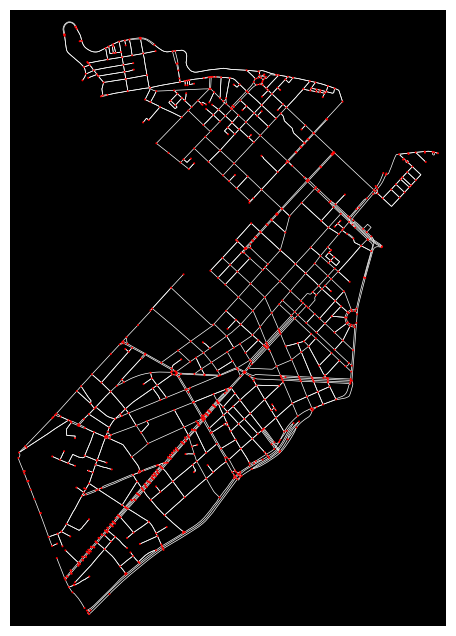


--- PHÂN TÍCH CƠ BẢN MẠNG LƯỚI GIAO THÔNG ---
Số lượng nút giao (nodes/intersections): 985
Số lượng đoạn đường (edges): 2081
Chiều dài đoạn đường trung bình: 81.53 mét
Mật độ nút giao (ước tính): 123.48 nút/km²


In [ ]:
# Cài đặt các thư viện cần thiết (chạy lệnh này trong 1 cell riêng)
!pip install osmnx networkx

# Import thư viện
import osmnx as ox
import networkx as nx

# Cấu hình osmnx (hiển thị log và sử dụng bộ nhớ đệm cache)
ox.settings.log_console = True
ox.settings.use_cache = True

# 1. Tải dữ liệu mạng lưới giao thông của một khu vực đô thị
# Dựa trên ví dụ trong tài liệu, ta dùng Quận 1, TP.HCM
place = "District 1, Ho Chi Minh City, Vietnam"
print(f"Đang tải dữ liệu mạng lưới đường bộ cho: {place}...")

# Lấy mạng lưới đường bộ cho phương tiện giao thông (drive). Có thể thay bằng 'walk' cho người đi bộ
G = ox.graph_from_place(place, network_type='drive')

# 2. Trực quan hóa mạng đường trên bản đồ
print("Đang trực quan hóa mạng lưới...")
# Vẽ mạng lưới dưới dạng đồ thị (graph) với nền đen, đường màu trắng
fig, ax = ox.plot_graph(G, node_size=2, node_color='red', edge_color='white', edge_linewidth=0.5, bgcolor='black')

# 3. Thực hiện một số phân tích cơ bản
print("\n--- PHÂN TÍCH CƠ BẢN MẠNG LƯỚI GIAO THÔNG ---")

# Tính số lượng nút giao (Nodes)
num_nodes = len(G.nodes)
print(f"Số lượng nút giao (nodes/intersections): {num_nodes}")

# Tính số lượng đoạn đường nối (Edges)
num_edges = len(G.edges)
print(f"Số lượng đoạn đường (edges): {num_edges}")

# Tính toán các thống kê chuẩn hóa bằng hàm basic_stats của osmnx
basic_stats = ox.basic_stats(G)

# Chiều dài đường trung bình
avg_street_length = basic_stats.get('street_length_avg', 0)
print(f"Chiều dài đoạn đường trung bình: {avg_street_length:.2f} mét")

# Tính mật độ nút giao trên km2
# Bước này cần tính diện tích khu vực bằng cách chuyển đổi hệ tọa độ
area_sqm = ox.geocode_to_gdf(place).to_crs(epsg=3395).area.values[0] # Diện tích theo mét vuông
area_sqkm = area_sqm / 1e6 # Đổi ra km vuông
intersection_density = num_nodes / area_sqkm
print(f"Mật độ nút giao (ước tính): {intersection_density:.2f} nút/km²")

In [ ]:
# !pip install osmnx networkx folium geopy

import osmnx as ox
import networkx as nx
import folium
import math

# 1. Tải mạng lưới giao thông (Dựa theo slide 74)
place = "District 1, Ho Chi Minh City, Vietnam"
# Tải đồ thị đường đi bộ (walk). Có thể đổi thành 'drive' nếu muốn tìm đường ô tô
G_walk = ox.graph_from_place(place, network_type='walk')

# 2. Định nghĩa tọa độ điểm Bắt đầu và Kết thúc
# Chợ Bến Thành
origin_coords = (10.7724, 106.6981)
# Saigon Centre
dest_coords = (10.7731, 106.7011)

# 3. Ánh xạ tọa độ GPS vào các Node gần nhất trên đồ thị NetworkX
orig_node = ox.distance.nearest_nodes(G_walk, X=origin_coords[1], Y=origin_coords[0])
dest_node = ox.distance.nearest_nodes(G_walk, X=dest_coords[1], Y=dest_coords[0])

# ==========================================
# 4. THUẬT TOÁN 1: DIJKSTRA
# ==========================================
# Trong NetworkX, hàm shortest_path mặc định dùng thuật toán Dijkstra khi có khai báo weight
path_dijkstra = nx.shortest_path(G_walk, orig_node, dest_node, weight='length')
len_dijkstra = nx.shortest_path_length(G_walk, orig_node, dest_node, weight='length')

# ==========================================
# 5. THUẬT TOÁN 2: A* (A-STAR SEARCH)
# ==========================================
# Thuật toán A* yêu cầu một hàm Heuristic để ước lượng khoảng cách từ node hiện tại đến đích.
# Ở đây ta dùng khoảng cách đường chim bay (Euclidean distance quy đổi ra mét).
def heuristic(node1, node2):
    y1, x1 = G_walk.nodes[node1]['y'], G_walk.nodes[node1]['x']
    y2, x2 = G_walk.nodes[node2]['y'], G_walk.nodes[node2]['x']
    # 1 độ địa lý xấp xỉ 111,000 mét
    return math.sqrt((y2 - y1)**2 + (x2 - x1)**2) * 111000

path_astar = nx.astar_path(G_walk, orig_node, dest_node, heuristic=heuristic, weight='length')
len_astar = nx.astar_path_length(G_walk, orig_node, dest_node, heuristic=heuristic, weight='length')

print(f"Khoảng cách đi bộ theo Dijkstra: {len_dijkstra:.2f} mét")
print(f"Khoảng cách đi bộ theo A*: {len_astar:.2f} mét")

# Kiểm tra xem hai thuật toán có cho ra cùng một tuyến đường hay không
if path_dijkstra == path_astar:
    print("-> Nhận xét: Cả hai thuật toán đều tìm ra cùng một tuyến đường tối ưu nhất.")

# ==========================================
# 6. TRỰC QUAN HÓA BẢN ĐỒ BẰNG FOLIUM
# ==========================================
# Trích xuất tọa độ của các node trên tuyến đường đã tìm được
route_coords = [(G_walk.nodes[n]['y'], G_walk.nodes[n]['x']) for n in path_astar]

# Khởi tạo bản đồ tại điểm xuất phát
m = folium.Map(location=origin_coords, zoom_start=16)

# Vẽ đường đi (PolyLine) dựa trên lý thuyết slide 73
folium.PolyLine(
    locations=route_coords,
    color='blue',
    weight=6,
    opacity=0.7,
    tooltip=f"Tuyến đường đi bộ: {len_astar:.0f}m"
).add_to(m)

# Đánh dấu điểm Đầu và Cuối
folium.Marker(origin_coords, popup="Chợ Bến Thành (Bắt đầu)", icon=folium.Icon(color='green', icon='play')).add_to(m)
folium.Marker(dest_coords, popup="Saigon Centre (Kết thúc)", icon=folium.Icon(color='red', icon='stop')).add_to(m)

# Hiển thị bản đồ
m

Khoảng cách đi bộ theo Dijkstra: 507.98 mét
Khoảng cách đi bộ theo A*: 507.98 mét
-> Nhận xét: Cả hai thuật toán đều tìm ra cùng một tuyến đường tối ưu nhất.


In [ ]:
import osmnx as ox
import networkx as nx
import folium
import random
import numpy as np

# 1. Khởi tạo bản đồ và dữ liệu mạng lưới
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# 2. Tạo dữ liệu giả lập cho Khách hàng và Tài xế
num_customers = 3
num_drivers = 5

# Lấy ngẫu nhiên các nút trên đồ thị để đặt vị trí
all_nodes = list(G.nodes)
customer_nodes = random.sample(all_nodes, num_customers)
driver_nodes = random.sample(all_nodes, num_drivers)

# 3. Thuật toán Heuristic: Greedy Assignment
# Với mỗi khách hàng, tìm tài xế có quãng đường bộ ngắn nhất
assignments = []
available_drivers = list(driver_nodes)

for customer in customer_nodes:
    best_driver = None
    shortest_dist = float('inf')
    best_route = None

    for driver in available_drivers:
        try:
            # Tính khoảng cách đường bộ ngắn nhất bằng Dijkstra (mặc định trong nx)
            dist = nx.shortest_path_length(G, source=driver, target=customer, weight='length')
            if dist < shortest_dist:
                shortest_dist = dist
                best_driver = driver
        except nx.NetworkXNoPath:
            continue

    if best_driver:
        # Tìm đường đi chi tiết để vẽ lên bản đồ
        route = nx.shortest_path(G, source=best_driver, target=customer, weight='length')
        assignments.append({
            'customer': customer,
            'driver': best_driver,
            'route': route,
            'distance': shortest_dist
        })
        # Sau khi gán, tài xế này không còn trống (tùy chọn)
        available_drivers.remove(best_driver)

# 4. Trực quan hóa bằng Folium
# Tâm bản đồ
m = folium.Map(location=[10.776, 106.701], zoom_start=15)

# Vẽ vị trí các khách hàng (Màu Đỏ)
for c_node in customer_nodes:
    node_data = G.nodes[c_node]
    folium.Marker([node_data['y'], node_data['x']],
                  popup="Khách hàng", icon=folium.Icon(color='red', icon='user')).add_to(m)

# Vẽ vị trí các tài xế (Màu Xanh)
for d_node in driver_nodes:
    node_data = G.nodes[d_node]
    folium.Marker([node_data['y'], node_data['x']],
                  popup="Tài xế", icon=folium.Icon(color='blue', icon='car')).add_to(m)

# Vẽ đường đi đã được gán (Màu xanh lá)
for asn in assignments:
    route_coords = [[G.nodes[n]['y'], G.nodes[n]['x']] for n in asn['route']]
    folium.PolyLine(route_coords, color="green", weight=5, opacity=0.7,
                    tooltip=f"Distance: {asn['distance']:.1f}m").add_to(m)

print(f"Hệ thống đã kết nối thành công {len(assignments)} cặp khách hàng - tài xế.")
m

Hệ thống đã kết nối thành công 3 cặp khách hàng - tài xế.


In [ ]:
import osmnx as ox
import networkx as nx
import folium

# Cấu hình osmnx
ox.settings.log_console = True
ox.settings.use_cache = True

print("1. Đang tải dữ liệu mạng lưới giao thông Quận 1...")
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')
# Thêm thuộc tính tốc độ và thời gian di chuyển chuẩn cho các đoạn đường
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

print("2. Định vị điểm xuất phát và đích đến...")
orig_coords = ox.geocode("Ben Thanh Market, Ho Chi Minh City, Vietnam")
dest_coords = ox.geocode("Saigon Zoo and Botanical Gardens, Ho Chi Minh City, Vietnam")

orig_node = ox.distance.nearest_nodes(G, X=orig_coords[1], Y=orig_coords[0])
dest_node = ox.distance.nearest_nodes(G, X=dest_coords[1], Y=dest_coords[0])

# --- BƯỚC 1: TÌM TUYẾN ĐƯỜNG NGẮN NHẤT THEO LÝ THUYẾT (KHI ĐƯỜNG THÔNG THOÁNG) ---
route_shortest = nx.shortest_path(G, orig_node, dest_node, weight='length')

# --- BƯỚC 2: MÔ PHỎNG AI XÁC ĐỊNH VÙNG NGUY CƠ KẸT XE ---
print("3. Cập nhật dữ liệu giao thông mô phỏng (Tạo điểm kẹt xe)...")
# Khởi tạo thuộc tính 'current_time' (thời gian thực tế) bằng thời gian chuẩn
for u, v, k, data in G.edges(keys=True, data=True):
    data['current_time'] = data['travel_time']

# Giả sử có một vụ kẹt xe nghiêm trọng nằm ngay giữa đoạn đường đi (bán kính 500m)
mid_node = route_shortest[len(route_shortest)//2]
# Lấy tất cả các nút nằm trong bán kính 500m từ tâm kẹt xe
nodes_in_jam = nx.ego_graph(G, mid_node, radius=500, distance='length').nodes()

congested_edges = []
for u, v, k, data in G.edges(keys=True, data=True):
    if u in nodes_in_jam or v in nodes_in_jam:
        # Tăng thời gian di chuyển qua khu vực này lên gấp 10 lần (Kẹt xe nặng)
        data['current_time'] = data['travel_time'] * 10
        congested_edges.append((u, v))

# --- BƯỚC 3: TÌM TUYẾN ĐƯỜNG THAY THẾ BẰNG AI ---
print("4. Đang tính toán tuyến đường thay thế tối ưu...")
# Lúc này AI dùng Dijkstra/A* nhưng trọng số (weight) là 'current_time' thay vì khoảng cách vật lý
route_alternative = nx.shortest_path(G, orig_node, dest_node, weight='current_time')

# --- BƯỚC 4: TRỰC QUAN HÓA BẢN ĐỒ ---
print("\n5. Hiển thị bản đồ phân tích giao thông:")
m = folium.Map(location=[10.776, 106.701], zoom_start=14, tiles='CartoDB dark_matter')

# 1. Vẽ VÙNG RỦI RO KẸT XE (Màu đỏ mờ)
for u, v in congested_edges:
    node_u, node_v = G.nodes[u], G.nodes[v]
    folium.PolyLine(
        locations=[[node_u['y'], node_u['x']], [node_v['y'], node_v['x']]],
        color='red', weight=3, opacity=0.4
    ).add_to(m)

# 2. Vẽ tuyến đường LÝ THUYẾT (Màu xám, đứt nét - đã bị kẹt)
route_shortest_coords = [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route_shortest]
folium.PolyLine(
    route_shortest_coords, color='gray', weight=4, dash_array='10',
    tooltip="Đường đi ngắn nhất (Đang kẹt xe)"
).add_to(m)

# 3. Vẽ TUYẾN ĐƯỜNG THAY THẾ (Màu xanh lá rực rỡ)
route_alt_coords = [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route_alternative]
folium.PolyLine(
    route_alt_coords, color='#00FF00', weight=6, opacity=0.9,
    tooltip="Tuyến đường thay thế (An toàn)"
).add_to(m)

# Thêm marker xuất phát và đích
folium.Marker([orig_coords[0], orig_coords[1]], popup="Điểm đi", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker([dest_coords[0], dest_coords[1]], popup="Điểm đến", icon=folium.Icon(color='orange')).add_to(m)

m

1. Đang tải dữ liệu mạng lưới giao thông Quận 1...
2. Định vị điểm xuất phát và đích đến...
3. Cập nhật dữ liệu giao thông mô phỏng (Tạo điểm kẹt xe)...
4. Đang tính toán tuyến đường thay thế tối ưu...

5. Hiển thị bản đồ phân tích giao thông:


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import folium
from folium.plugins import HeatMap

# --- 1. TẠO DỮ LIỆU GIẢ LẬP KHÔNG GIAN & THỜI GIAN ---
np.random.seed(42)
n_samples = 3000

# Khởi tạo 3 tâm điểm: 1 Khu văn phòng (Q1), 2 Khu dân cư (Q7, Q2)
hotspots = [
    {"lat": 10.776, "lon": 106.701, "type": "office", "name": "District 1"},
    {"lat": 10.732, "lon": 106.701, "type": "residential", "name": "District 7"},
    {"lat": 10.803, "lon": 106.739, "type": "residential", "name": "District 2"}
]

data = []
for _ in range(n_samples):
    spot = np.random.choice(hotspots)
    # Thêm độ nhiễu để các điểm tỏa ra xung quanh tâm
    lat = np.random.normal(spot["lat"], 0.015)
    lon = np.random.normal(spot["lon"], 0.015)
    hour = np.random.randint(0, 24) # Giờ từ 0 đến 23

    # Logic sinh dữ liệu (Heuristic giả lập thực tế)
    base_demand = np.random.randint(1, 5)
    if spot["type"] == "office":
        # Văn phòng đỉnh điểm lúc 17h-18h (tan làm) và 11h-12h (ăn trưa)
        if hour in [17, 18, 19]:
            demand = base_demand * 6
        elif hour in [11, 12]:
            demand = base_demand * 4
        else:
            demand = base_demand
    else:
        # Dân cư đỉnh điểm lúc 7h-8h sáng (rời khỏi nhà đi làm)
        if hour in [7, 8]:
            demand = base_demand * 5
        else:
            demand = base_demand

    data.append([lat, lon, hour, demand])

df = pd.DataFrame(data, columns=['lat', 'lon', 'hour', 'demand'])

# --- 2. HUẤN LUYỆN MÔ HÌNH HỌC MÁY ---
print("Đang huấn luyện mô hình Random Forest...")
X = df[['lat', 'lon', 'hour']]
y = df['demand']

# Random Forest rất phù hợp cho dữ liệu phi tuyến tính như tọa độ
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# --- 3. DỰ ĐOÁN NHU CẦU THEO LƯỚI KHÔNG GIAN CHO MỘT KHUNG GIỜ ---
target_hour = 18 # THAY ĐỔI GIỜ Ở ĐÂY ĐỂ XEM SỰ KHÁC BIỆT (Ví dụ: 8 cho 8h sáng)
print(f"Đang dự báo nhu cầu giao thông lúc {target_hour}:00...")

# Tạo một lưới tọa độ bao phủ thành phố để dự đoán
lat_grid = np.linspace(df['lat'].min(), df['lat'].max(), 40)
lon_grid = np.linspace(df['lon'].min(), df['lon'].max(), 40)
grid_points = [[lat, lon, target_hour] for lat in lat_grid for lon in lon_grid]

X_pred = pd.DataFrame(grid_points, columns=['lat', 'lon', 'hour'])
predicted_demand = model.predict(X_pred)

# --- 4. TRỰC QUAN HÓA BẢN ĐỒ NHIỆT (HEATMAP) ---
m = folium.Map(location=[10.770, 106.715], zoom_start=12, tiles='CartoDB dark_matter')

# Chuẩn bị dữ liệu cho Heatmap: [vĩ độ, kinh độ, trọng số nhu cầu]
heat_data = [[row.lat, row.lon, demand] for row, demand in zip(X_pred.itertuples(), predicted_demand)]

# Thêm lớp Heatmap vào bản đồ
HeatMap(heat_data, radius=18, blur=13, max_zoom=1).add_to(m)

# Thêm marker ghi chú các khu vực
folium.Marker([10.776, 106.701], popup="Quận 1 (Văn phòng)").add_to(m)
folium.Marker([10.732, 106.701], popup="Quận 7 (Dân cư)").add_to(m)
folium.Marker([10.803, 106.739], popup="Quận 2 (Dân cư)").add_to(m)

m

Đang huấn luyện mô hình Random Forest...
Đang dự báo nhu cầu giao thông lúc 18:00...


In [ ]:
# 1. Cài đặt các thư viện cần thiết
!pip install ortools folium geopy

import folium
from geopy.distance import geodesic
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# 2. Khởi tạo dữ liệu: 2 Kho (Kho A, Kho B) và 5 Điểm giao nhận (Khách 1 -> 5)
locations = {
    "Kho A": (10.7769, 106.7009),   # Index 0
    "Kho B": (10.7600, 106.6900),   # Index 1
    "Khách 1": (10.7800, 106.7100), # Index 2
    "Khách 2": (10.7900, 106.7000), # Index 3
    "Khách 3": (10.7700, 106.6800), # Index 4
    "Khách 4": (10.7850, 106.7300), # Index 5
    "Khách 5": (10.7500, 106.6800), # Index 6
}
location_names = list(locations.keys())
coordinates = list(locations.values())

# 3. Tính toán ma trận khoảng cách (đơn vị: mét)
distance_matrix = []
for from_coord in coordinates:
    row = []
    for to_coord in coordinates:
        # Tính khoảng cách thực tế bằng geodesic
        distance = geodesic(from_coord, to_coord).km
        row.append(int(distance * 1000))
    distance_matrix.append(row)

# 4. ĐÁNH GIÁ PHƯƠNG ÁN KHÔNG TỐI ƯU
# Giả sử Xe 1 đi tuần tự theo danh sách Khách 1->2->3 rồi về Kho A
# Giả sử Xe 2 đi tuần tự Khách 4->5 rồi về Kho B
def calculate_route_distance(route_indices):
    dist = 0
    for i in range(len(route_indices) - 1):
        dist += distance_matrix[route_indices[i]][route_indices[i+1]]
    return dist

unopt_route_1 = [0, 2, 3, 4, 0]
unopt_route_2 = [1, 5, 6, 1]
total_unopt_dist = (calculate_route_distance(unopt_route_1) + calculate_route_distance(unopt_route_2)) / 1000

print(f"--- ĐÁNH GIÁ TRƯỚC TỐI ƯU ---")
print(f"Tổng khoảng cách đi tuần tự (không tối ưu): {total_unopt_dist:.2f} km\n")

# 5. TỐI ƯU HÓA BẰNG OR-TOOLS & HEURISTIC
def create_data_model():
    data = {}
    data['distance_matrix'] = distance_matrix
    data['num_vehicles'] = 2
    # Khai báo Đa kho: Xe 1 xuất phát & về Kho A (index 0), Xe 2 xuất phát & về Kho B (index 1)
    data['starts'] = [0, 1]
    data['ends'] = [0, 1]
    return data

data = create_data_model()
manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']), data['num_vehicles'], data['starts'], data['ends'])
routing = pywrapcp.RoutingModel(manager)

# Hàm chi phí khoảng cách
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# Cấu hình thuật toán Heuristic: PATH_CHEAPEST_ARC
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)

solution = routing.SolveWithParameters(search_parameters)

# 6. KẾT QUẢ & TRỰC QUAN HÓA TRÊN BẢN ĐỒ FOLIUM
m = folium.Map(location=[10.770, 106.700], zoom_start=13)
colors = ['blue', 'green']

if solution:
    print(f"--- ĐÁNH GIÁ SAU TỐI ƯU ---")
    total_opt_dist = 0
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_distance = 0
        route_coords = []
        print(f"Lộ trình Xe {vehicle_id + 1}:")

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            print(f" → {location_names[node]}", end="")
            route_coords.append(coordinates[node])
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        node = manager.IndexToNode(index)
        route_coords.append(coordinates[node])
        print(f" → {location_names[node]}")
        print(f"   Khoảng cách: {route_distance / 1000:.2f} km\n")
        total_opt_dist += route_distance

        # Vẽ lộ trình của xe
        folium.PolyLine(route_coords, color=colors[vehicle_id], weight=4, opacity=0.8).add_to(m)

    opt_km = total_opt_dist / 1000
    print(f"Tổng khoảng cách TỐI ƯU: {opt_km:.2f} km")
    print(f"✅ HIỆU QUẢ: Thuật toán Heuristic đã giúp tiết kiệm {(total_unopt_dist - opt_km):.2f} km so với phương án đi ngẫu nhiên.")
else:
    print("Không tìm được giải pháp.")

# Vẽ Marker cho các Kho (màu đỏ) và Khách hàng (màu cam)
for name, coord in locations.items():
    if "Kho" in name:
        folium.Marker(coord, popup=name, icon=folium.Icon(color='red', icon='home')).add_to(m)
    else:
        folium.Marker(coord, popup=name, icon=folium.Icon(color='orange')).add_to(m)

# Hiển thị bản đồ (chỉ áp dụng trên Jupyter Notebook / Colab)
m

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 24.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21

--- ĐÁNH GIÁ TRƯỚC TỐI ƯU ---
Tổng khoảng cách đi tuần tự (không tối ưu): 21.56 km

--- ĐÁNH GIÁ SAU TỐI ƯU ---
Lộ trình Xe 1:
 → Kho A → Khách 2 → Khách 4 → Khách 1 → Kho A
   Khoảng cách: 8.09 km

Lộ trình Xe 2:
 → Kho B → Khách 3 → Khách 5 → Kho B
   Khoảng cách: 5.32 km

Tổng khoảng cách TỐI ƯU: 13.41 km
✅ HIỆU QUẢ: Thuật toán Heuristic đã giúp tiết kiệm 8.15 km so với phương án đi ngẫu nhiên.


In [ ]:
# 1. Cài đặt thư viện
!pip install osmnx folium networkx

import osmnx as ox
import networkx as nx
import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta

# 2. Tải mạng lưới đường phố (Ví dụ: Quận 1, TP.HCM)
place_name = "District 1, Ho Chi Minh City, Vietnam"
# Lấy đồ thị giao thông cho xe ô tô
G = ox.graph_from_place(place_name, network_type='drive')
G = ox.project_graph(G) # Chuyển sang hệ tọa độ phẳng để tính toán chính xác

# 3. Xác định điểm đi và điểm đến (Toạ độ thực tế)
origin_point = (10.7769, 106.7009) # Bitexco
destination_point = (10.7795, 106.6990) # Chợ Bến Thành

# Tìm node gần nhất trên mạng lưới đường
origin_node = ox.distance.nearest_nodes(G, X=origin_point[1], Y=origin_point[0])
dest_node = ox.distance.nearest_nodes(G, X=destination_point[1], Y=destination_point[0])

# 4. Tìm đường đi ngắn nhất trên mạng lưới đường thực
route = nx.shortest_path(G, origin_node, dest_node, weight='length')

# Lấy tọa độ (lat, lon) của các node trong lộ trình
route_coords = []
for node in route:
    node_data = G.nodes[node]
    # Do đã project nên cần lấy tọa độ x, y chuyển lại lat, lon hoặc lấy từ bản đồ gốc
    # Ở đây ta lấy trực tiếp từ dữ liệu node của OSM
    route_coords.append([node_data['y'], node_data['x']])

# 5. Tạo dữ liệu mô phỏng theo thời gian (Timestamped Data)
features = []
start_time = datetime(2023, 10, 1, 8, 0, 0)

for i, coord in enumerate(route_coords):
    # Giả sử mỗi bước di chuyển mất 30 giây
    current_time = (start_time + timedelta(seconds=i * 30)).isoformat()

    feature = {
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [coord[1], coord[0]], # GeoJSON dùng [lon, lat]
        },
        'properties': {
            'time': current_time,
            'style': {'color': 'red'},
            'icon': 'marker',
            'iconstyle': {
                'iconShape': 'bookmark',
                'iconSize': [20, 20]
            },
            'popup': f"Xe đang ở Node {i} lúc {current_time}"
        }
    }
    features.append(feature)

# 6. Khởi tạo bản đồ và thêm hiệu ứng hoạt ảnh
m = folium.Map(location=origin_point, zoom_start=16)

# Thêm đường đi tĩnh để dễ quan sát
folium.PolyLine(route_coords, color="blue", weight=2, opacity=0.5).add_to(m)

# Thêm Plugin hoạt ảnh theo thời gian
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='PT30S', # Bước nhảy thời gian
    add_last_point=True,
    auto_play=True,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options='YYYY-MM-DD HH:mm:ss',
).add_to(m)

m

In [ ]:
# 1. Cài đặt các gói cần thiết
!pip install osmnx networkx folium scikit-learn numpy

import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
import numpy as np
import osmnx as ox
import networkx as nx

# 2. Khởi tạo dữ liệu giả lập (Nhu cầu sạc xe tại trung tâm TP.HCM)
center_lat, center_lon = 10.7769, 106.7009
np.random.seed(42)
# Tạo 500 điểm nhu cầu sạc ngẫu nhiên xung quanh khu vực trung tâm (độ lệch chuẩn 0.015 độ)
demand_lats = np.random.normal(center_lat, 0.015, 500)
demand_lons = np.random.normal(center_lon, 0.015, 500)
demand_points = np.column_stack((demand_lats, demand_lons))

# 3. PHƯƠNG PHÁP AI 1: Phân cụm K-Means để tìm vị trí đặt Trạm Sạc
# Giả sử chúng ta có ngân sách xây dựng 3 trạm sạc lớn (Clusters = 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(demand_points)
charging_stations = kmeans.cluster_centers_ # Tọa độ tối ưu của 3 trạm sạc

# 4. PHƯƠNG PHÁP AI 2: Tìm đường (Routing) cho một xe đang hết pin
# Tải mạng lưới đường phố (Lấy một khu vực nhỏ để code chạy nhanh trên Colab)
G = ox.graph_from_point((center_lat, center_lon), dist=2000, network_type='drive')

# Vị trí xe đang hết pin (Giả định)
car_location = (10.7850, 106.6900)

# Tìm trạm sạc gần chiếc xe này nhất theo đường chim bay trước
distances_to_stations = [np.linalg.norm(np.array(car_location) - station) for station in charging_stations]
nearest_station = charging_stations[np.argmin(distances_to_stations)]

# Tìm node trên đồ thị đường phố cho xe và trạm sạc
orig_node = ox.distance.nearest_nodes(G, X=car_location[1], Y=car_location[0])
dest_node = ox.distance.nearest_nodes(G, X=nearest_station[1], Y=nearest_station[0])

# Tính toán lộ trình ngắn nhất bằng Dijkstra
try:
    route = nx.shortest_path(G, orig_node, dest_node, weight='length')
    route_coords = [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route]
except nx.NetworkXNoPath:
    route_coords = []
    print("Không tìm thấy đường đi trên mạng lưới.")

# 5. TRỰC QUAN HÓA TRÊN DASHBOARD BẢN ĐỒ
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='CartoDB positron')

# Lớp 1: Bản đồ nhiệt (Heatmap) thể hiện nhu cầu
HeatMap(demand_points.tolist(), radius=12, blur=10, gradient={0.4: 'blue', 0.6: 'lime', 1: 'red'}).add_to(m)

# Lớp 2: Vị trí Trạm Sạc do AI đề xuất (Markers)
for i, station in enumerate(charging_stations):
    folium.Marker(
        location=[station[0], station[1]],
        popup=f"Trạm sạc tự động {i+1}<br>Mô hình K-Means",
        icon=folium.Icon(color='green', icon='bolt', prefix='fa') # Icon sạc điện
    ).add_to(m)

# Lớp 3: Vị trí xe điện và Lộ trình tối ưu
folium.Marker(
    location=car_location,
    popup="Xe đang cần sạc khẩn cấp!",
    icon=folium.Icon(color='red', icon='car', prefix='fa')
).add_to(m)

if route_coords:
    folium.PolyLine(route_coords, color='blue', weight=5, opacity=0.8, tooltip="Lộ trình di chuyển").add_to(m)

# Hiển thị
m